# Case 3 – Nuclear + Data Center + Bidirectional Grid




In [1]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import os
from h2integrate import EXAMPLE_DIR
os.chdir(EXAMPLE_DIR / '32_nuclear_DC_case_3')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from h2integrate.core.h2integrate_model import H2IntegrateModel

warnings.filterwarnings('ignore')  # suppress OpenMDAO recording warnings

DC_DEMAND_MW = 2000  # fixed data-center demand [MW]

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/fastkml/__init__.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## 2. Load & inspect base model

In [2]:
h2i = H2IntegrateModel('nuclear_datacenter_config_case.yaml')
h2i.setup()

cap_kw     = h2i.prob.get_val('plant.nuclear.QuinnNuclearPerformanceModel.system_capacity', units='kW')
icx_buy_kw = h2i.prob.get_val('plant.grid_buy.GridPerformanceModel.interconnection_size',   units='kW')
icx_sell_kw= h2i.prob.get_val('plant.grid_sell.GridPerformanceModel.interconnection_size',  units='kW')

print(f'Default nuclear capacity      : {cap_kw[0]/1e3:.0f} MW')
print(f'grid_buy  interconnect size   : {icx_buy_kw[0]/1e3:.0f} MW')
print(f'grid_sell interconnect size   : {icx_sell_kw[0]/1e3:.0f} MW')
print(f'DC demand (fixed)             : {DC_DEMAND_MW} MW')

Default nuclear capacity      : 1000 MW
grid_buy  interconnect size   : 2000 MW
grid_sell interconnect size   : 3000 MW
DC demand (fixed)             : 2000 MW


## 3. 1-D Nuclear Size Sweep

DC demand is fixed at 2000 MW.  
`grid_buy` interconnection is fixed at DC demand size (2000 MW).  
`grid_sell` interconnection scales with nuclear size.

In [3]:
NUCLEAR_SIZES_MW = [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]

results = []
ts_data = {}   # hourly time-series keyed by nuclear_mw

for nuclear_mw in NUCLEAR_SIZES_MW:
    nuclear_kw = nuclear_mw * 1e3
    # Size grid interconnection to handle largest possible flow
    icx_kw_val = max(nuclear_kw, DC_DEMAND_MW * 1e3)

    h2i.prob.set_val('nuclear.system_capacity',   nuclear_kw,  units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', nuclear_kw, units='kW')  # nuclear runs at full capacity
    h2i.prob.set_val('grid_buy.interconnection_size',  DC_DEMAND_MW * 1e3, units='kW')  # max backup = DC demand
    h2i.prob.set_val('grid_sell.interconnection_size', nuclear_kw,         units='kW')  # max surplus = nuclear size

    h2i.run()

    # ---- Scalar outputs ----
    lcoe      = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', units='USD/(kW*h)')[0]
    nuc_capex = h2i.prob.get_val('nuclear.CapEx',   units='USD')[0] / 1e9
    grd_buy_capex  = h2i.prob.get_val('grid_buy.CapEx',   units='USD')[0] / 1e6
    grd_sell_capex = h2i.prob.get_val('grid_sell.CapEx',  units='USD')[0] / 1e6
    grd_capex = grd_buy_capex + grd_sell_capex
    nuc_opex  = h2i.prob.get_val('nuclear.OpEx',    units='USD/year')[0] / 1e6
    nuc_varop = h2i.prob.get_val('nuclear.VarOpEx', units='USD/year')[0] / 1e6
    grd_opex  = (h2i.prob.get_val('grid_buy.OpEx',  units='USD/year')[0]
              +  h2i.prob.get_val('grid_sell.OpEx', units='USD/year')[0]) / 1e6
    grd_buy_varop  = h2i.prob.get_val('grid_buy.VarOpEx',  units='USD/year')[0] / 1e6  # positive = buying cost
    grd_sell_varop = h2i.prob.get_val('grid_sell.VarOpEx', units='USD/year')[0] / 1e6  # negative = sell revenue
    grd_varop = grd_buy_varop + grd_sell_varop

    # ---- Time-averaged flows (kW -> MW mean) ----
    surplus_mean_mw  = h2i.prob.get_val('electrical_load_demand.electricity_unused_commodity', units='kW').mean() / 1e3
    shortfall_mean_mw = h2i.prob.get_val('electrical_load_demand.electricity_unmet_demand',   units='kW').mean() / 1e3
    sold_mean_mw     = h2i.prob.get_val('grid_sell.electricity_sold', units='kW').mean() / 1e3
    bought_mean_mw   = h2i.prob.get_val('grid_buy.electricity_out',  units='kW').mean() / 1e3

    # ---- Annual energy (MWh) ----
    sold_gwh   = h2i.prob.get_val('grid_sell.electricity_sold', units='kW').sum() * 1e-6
    bought_gwh = h2i.prob.get_val('grid_buy.electricity_out',  units='kW').sum() * 1e-6

    results.append({
        'nuclear_mw':          nuclear_mw,
        'lcoe_per_mwh':        lcoe * 1000,          # USD/MWh
        'capacity_factor':     h2i.prob.get_val('nuclear.capacity_factor')[0],
        # Flows
        'surplus_mean_mw':     surplus_mean_mw,
        'shortfall_mean_mw':   shortfall_mean_mw,
        'sold_to_grid_mw':     sold_mean_mw,
        'bought_from_grid_mw': bought_mean_mw,
        'sold_gwh':            sold_gwh,
        'bought_gwh':          bought_gwh,
        # Costs ($B / $M)
        'nuclear_capex_B$':    nuc_capex,
        'grid_capex_M$':       grd_capex,
        'nuclear_opex_M$':     nuc_opex,
        'nuclear_varopex_M$':  nuc_varop,
        'grid_opex_M$':        grd_opex,
        'grid_varopex_M$':     grd_varop,   # negative = net revenue earned
        'net_grid_revenue_M$': -grd_varop,  # positive = revenue (buy_cost - sell_revenue sign flipped)
    })

    ts_data[nuclear_mw] = {
        'nuclear_out_mw':    h2i.prob.get_val('nuclear.electricity_out',                           units='kW') / 1e3,
        'surplus_mw':        h2i.prob.get_val('electrical_load_demand.electricity_unused_commodity', units='kW') / 1e3,
        'shortfall_mw':      h2i.prob.get_val('electrical_load_demand.electricity_unmet_demand',   units='kW') / 1e3,
        'sold_to_grid_mw':     h2i.prob.get_val('grid_sell.electricity_sold', units='kW') / 1e3,
        'bought_from_grid_mw': h2i.prob.get_val('grid_buy.electricity_out',  units='kW') / 1e3,
    }

df = pd.DataFrame(results)
df

,nuclear_mw,lcoe_per_mwh,capacity_factor,surplus_mean_mw,shortfall_mean_mw,sold_to_grid_mw,bought_from_grid_mw,sold_gwh,bought_gwh,nuclear_capex_B$,grid_capex_M$,nuclear_opex_M$,nuclear_varopex_M$,grid_opex_M$,grid_varopex_M$,net_grid_revenue_M$
0,500,133.752963,1.0,0.0,1500.0,0.0,1500.0,0.0,13140.0,4.555234,250.0,0.0,122.64,12.50,1051.2,-1051.2
1,750,121.505526,1.0,0.0,1250.0,0.0,1250.0,0.0,10950.0,6.050268,275.0,0.0,183.96,13.75,876.0,-876.0
2,1000,113.676332,1.0,0.0,1000.0,0.0,1000.0,0.0,8760.0,7.400000,300.0,0.0,245.28,15.00,700.8,-700.8
3,1250,108.052172,1.0,0.0,750.0,0.0,750.0,0.0,6570.0,8.651048,325.0,0.0,306.60,16.25,525.6,-525.6
4,1500,103.728322,1.0,0.0,500.0,0.0,500.0,0.0,4380.0,9.828689,350.0,0.0,367.92,17.50,350.4,-350.4
5,1750,100.252613,1.0,0.0,250.0,0.0,250.0,0.0,2190.0,10.948594,375.0,0.0,429.24,18.75,175.2,-175.2
6,2000,97.369040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12.021335,400.0,0.0,490.56,20.00,0.0,-0.0
7,2250,94.919683,1.0,250.0,0.0,250.0,0.0,2190.0,0.0,13.054477,425.0,0.0,551.88,21.25,-109.5,109.5
8,2500,92.800803,1.0,500.0,0.0,500.0,0.0,4380.0,0.0,14.053669,450.0,0.0,613.20,22.50,-219.0,219.0
9,2750,90.940893,1.0,750.0,0.0,750.0,0.0,6570.0,0.0,15.023275,475.0,0.0,674.52,23.75,-328.5,328.5


In [4]:
df["grid_varopex_M$"]

0     1051.2
1      876.0
2      700.8
3      525.6
4      350.4
5      175.2
6        0.0
7     -109.5
8     -219.0
9     -328.5
10    -438.0
Name: grid_varopex_M$, dtype: float64

## 4. 1-D Sweep – Visualizations

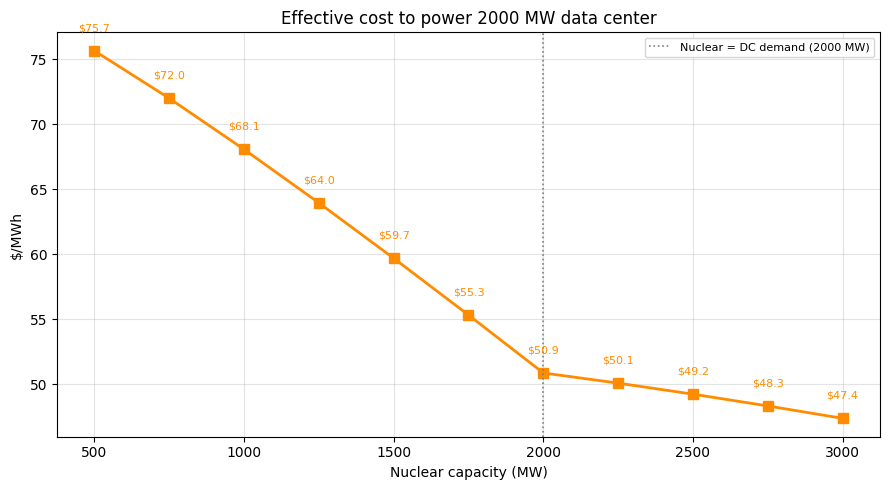

In [5]:
# ── Effective cost to power the DC ────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

DC_MWH_PER_YEAR = DC_DEMAND_MW * 8760          # MWh/yr

sizes = df['nuclear_mw'].values.astype(float)

# Grid cash flows ($M/yr)
grid_sell_rev_m = np.clip(-df['grid_varopex_M$'].values, 0, None)
grid_buy_cost_m = np.clip( df['grid_varopex_M$'].values, 0, None)

# Nuclear costs ($M/yr)
ann_capex_m          = df['nuclear_capex_B$'].values * 1e9 / 30 / 1e6   # $B → $M/yr
nuclear_total_cost_m = ann_capex_m + df['nuclear_opex_M$'].values + df['nuclear_varopex_M$'].values

# Effective cost ($/MWh)
numerator_usd_yr = (nuclear_total_cost_m + grid_buy_cost_m - grid_sell_rev_m) * 1e6  # $M/yr → $/yr
eff_cost_dc_mwh  = numerator_usd_yr / DC_MWH_PER_YEAR                                # $/MWh

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sizes, eff_cost_dc_mwh, 's-', color='darkorange', ms=7, lw=2)
ax.axvline(DC_DEMAND_MW, color='gray', lw=1.2, ls=':', label=f'Nuclear = DC demand ({DC_DEMAND_MW} MW)')

for s, e in zip(sizes, eff_cost_dc_mwh):
    ax.text(s, e + 1.5, f'${e:.1f}', ha='center', fontsize=8, color='darkorange')

ax.set_xlabel('Nuclear capacity (MW)')
ax.set_ylabel('$/MWh')
ax.set_title(f'Effective cost to power {DC_DEMAND_MW} MW data center')
ax.legend(fontsize=8)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


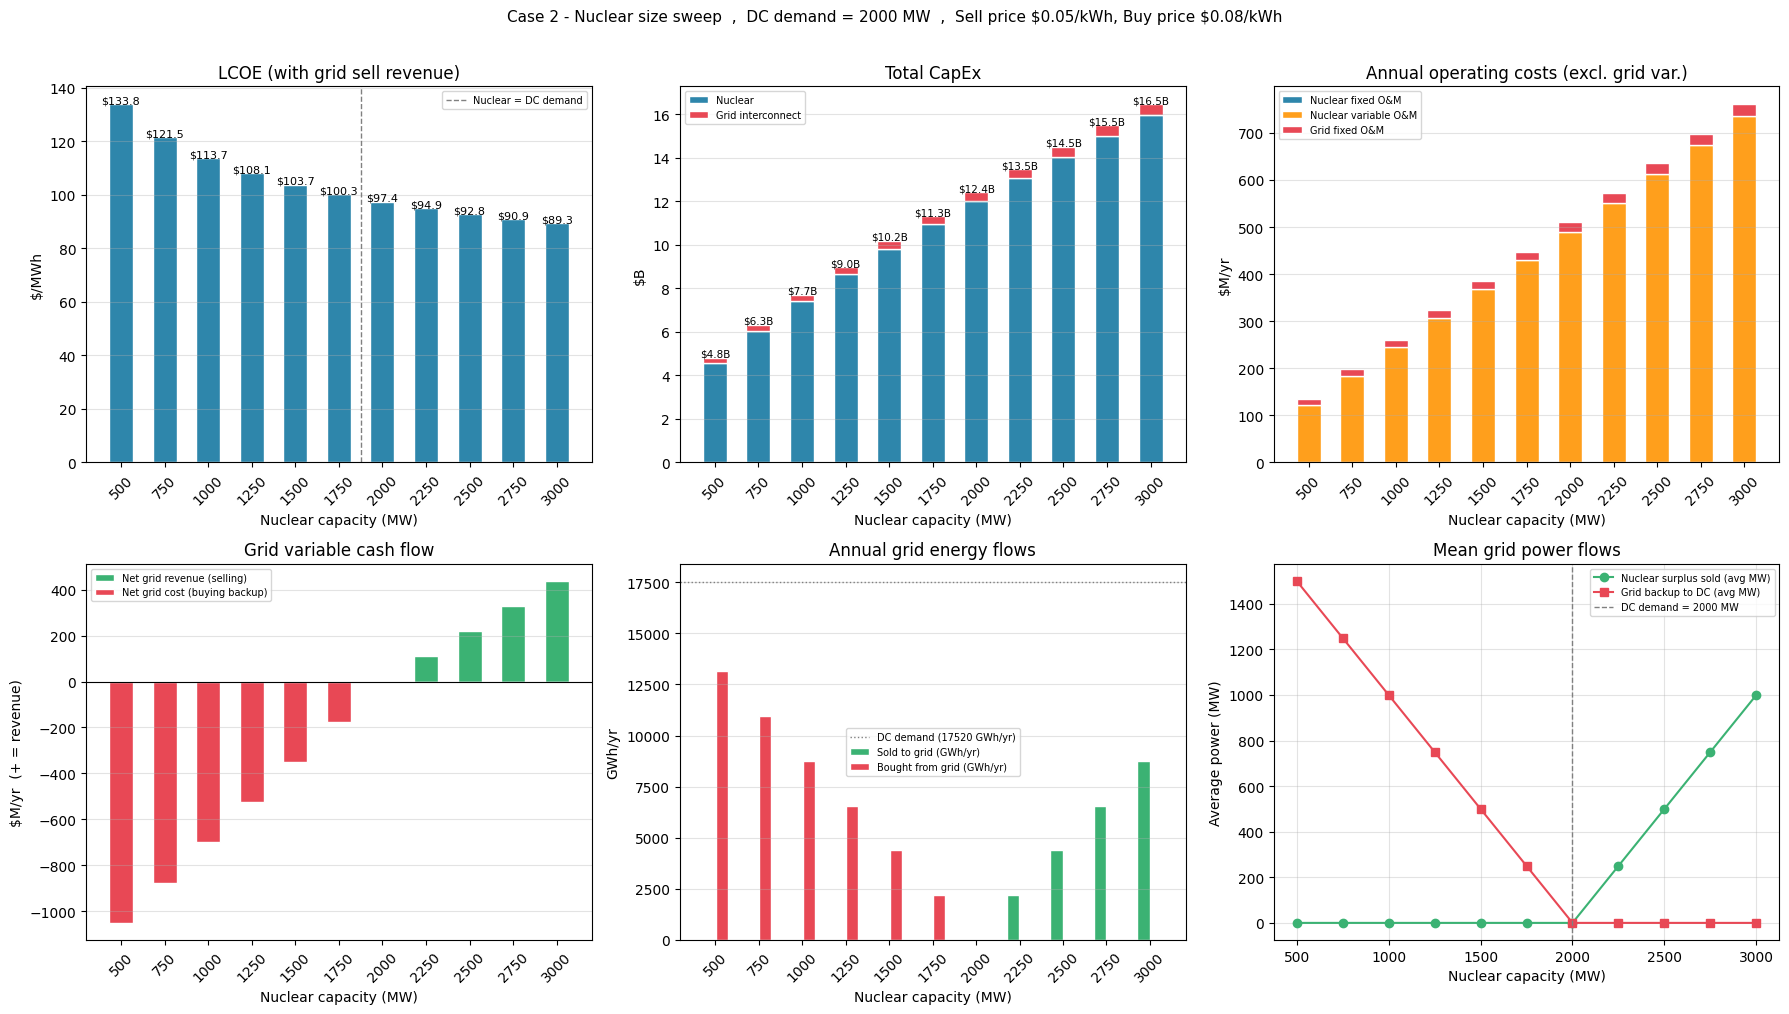

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.38)

sizes = df['nuclear_mw'].values.astype(float)
x     = np.arange(len(sizes))
labels = [str(int(s)) for s in sizes]
W = 0.55

# Color palette
C_NUC  = '#2e86ab'
C_GRD  = '#e84855'
C_REV  = '#3bb273'
C_COST = '#ff9f1c'

# ── 1. LCOE ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, df['lcoe_per_mwh'], W, color=C_NUC, edgecolor='white')
for xi, v in zip(x, df['lcoe_per_mwh']):
    ax.text(xi, v + 0.3, f'${v:.1f}', ha='center', fontsize=8)
ax.axvline(x=NUCLEAR_SIZES_MW.index(DC_DEMAND_MW) - 0.5, color='gray',
           linestyle='--', lw=1, label='Nuclear = DC demand')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$/MWh')
ax.set_title('LCOE (with grid sell revenue)')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 2. CapEx breakdown ────────────────────────────────────────────────────────
ax = axes[0, 1]
nuc_cx  = df['nuclear_capex_B$'].values
grd_cx  = df['grid_capex_M$'].values / 1e3
ax.bar(x, nuc_cx, W, color=C_NUC, label='Nuclear',          edgecolor='white')
ax.bar(x, grd_cx, W, bottom=nuc_cx, color=C_GRD, label='Grid interconnect', edgecolor='white')
for xi, n, g in zip(x, nuc_cx, grd_cx):
    ax.text(xi, (n + g) + 0.05, f'${n+g:.1f}B', ha='center', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$B')
ax.set_title('Total CapEx')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 3. Annual OpEx breakdown ──────────────────────────────────────────────────
ax = axes[0, 2]
op  = df['nuclear_opex_M$'].values
vop = df['nuclear_varopex_M$'].values
gop = df['grid_opex_M$'].values
ax.bar(x, op,      W, color=C_NUC,  label='Nuclear fixed O&M',    edgecolor='white')
ax.bar(x, vop,     W, bottom=op,           color=C_COST, label='Nuclear variable O&M', edgecolor='white')
ax.bar(x, gop,     W, bottom=op+vop,       color=C_GRD,  label='Grid fixed O&M',       edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$M/yr')
ax.set_title('Annual operating costs (excl. grid var.)')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 4. Grid variable revenue / cost ──────────────────────────────────────────
ax = axes[1, 0]
grd_rev  = np.clip(-df['grid_varopex_M$'].values, 0, None)   # positive = net revenue (sell > buy)
grd_cost = np.clip( df['grid_varopex_M$'].values, 0, None)   # positive = net cost (buy > sell)
ax.bar(x, grd_rev,  W, color=C_REV,  label='Net grid revenue (selling)',  edgecolor='white')
ax.bar(x, -grd_cost, W, color=C_GRD, label='Net grid cost (buying backup)', edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$M/yr  (+ = revenue)')
ax.set_title('Grid variable cash flow')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 5. Energy flows (annual GWh) ─────────────────────────────────────────────
ax = axes[1, 1]
sold   = df['sold_gwh'].values
bought = df['bought_gwh'].values
ax.bar(x - 0.15, sold,   0.28, color=C_REV,  label='Sold to grid (GWh/yr)',  edgecolor='white')
ax.bar(x + 0.15, bought, 0.28, color=C_GRD,  label='Bought from grid (GWh/yr)', edgecolor='white')
dc_gwh = DC_DEMAND_MW * 8760 / 1e3   # GWh/yr
ax.axhline(dc_gwh, color='gray', linestyle=':', lw=1, label=f'DC demand ({dc_gwh:.0f} GWh/yr)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('GWh/yr')
ax.set_title('Annual grid energy flows')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 6. Mean power flows (MW) ──────────────────────────────────────────────────
ax = axes[1, 2]
ax.plot(sizes, df['sold_to_grid_mw'],     'o-', color=C_REV,  label='Nuclear surplus sold (avg MW)')
ax.plot(sizes, df['bought_from_grid_mw'], 's-', color=C_GRD,  label='Grid backup to DC (avg MW)')
ax.axvline(DC_DEMAND_MW, color='gray', linestyle='--', lw=1, label=f'DC demand = {DC_DEMAND_MW} MW')
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('Average power (MW)')
ax.set_title('Mean grid power flows')
ax.legend(fontsize=7); ax.grid(alpha=0.35)

plt.suptitle(
    f'Case 2 - Nuclear size sweep  ,  DC demand = {DC_DEMAND_MW} MW  ,  '
    f'Sell price \$0.05/kWh, Buy price \$0.08/kWh',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('case3_1d_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 2-D Sweep – Nuclear Size × Customer Sell Price (NPV)

Grid is excluded from the LCOE numerator. Sweeping the grid sell price no longer affects LCOE.
Instead, sweep the **customer electricity sell price** to compute NPV across plant sizes.

In [7]:
## 6. 2-D Sweep – Nuclear Size × Customer Sell Price (NPV)

# Grid is excluded from LCOE numerator, so grid sell price does NOT change LCOE.
# Instead, sweep the PPA/customer electricity sell price to compute NPV.
SWEEP2_NUC_MW      = [500, 1000, 1500, 2000, 2500, 3000]
SWEEP2_SELL_PRICE  = [0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18]  # $/kWh

npv_matrix = np.zeros((len(SWEEP2_NUC_MW), len(SWEEP2_SELL_PRICE)))

for i, nuclear_mw in enumerate(SWEEP2_NUC_MW):
    nuclear_kw = nuclear_mw * 1e3
    h2i.prob.set_val('nuclear.system_capacity',    nuclear_kw, units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', nuclear_kw, units='kW')
    h2i.prob.set_val('grid_buy.interconnection_size',  DC_DEMAND_MW * 1e3, units='kW')
    h2i.prob.set_val('grid_sell.interconnection_size', nuclear_kw,         units='kW')

    for j, sell_p in enumerate(SWEEP2_SELL_PRICE):
        h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                         sell_p, units='USD/(kW*h)')
        h2i.run()
        npv_matrix[i, j] = h2i.prob.get_val(
            'finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9  # $B

    print(f'  Nuclear {nuclear_mw} MW done')

print('2-D NPV sweep complete.')


  Nuclear 500 MW done
  Nuclear 1000 MW done
  Nuclear 1500 MW done
  Nuclear 2000 MW done
  Nuclear 2500 MW done
  Nuclear 3000 MW done
2-D NPV sweep complete.


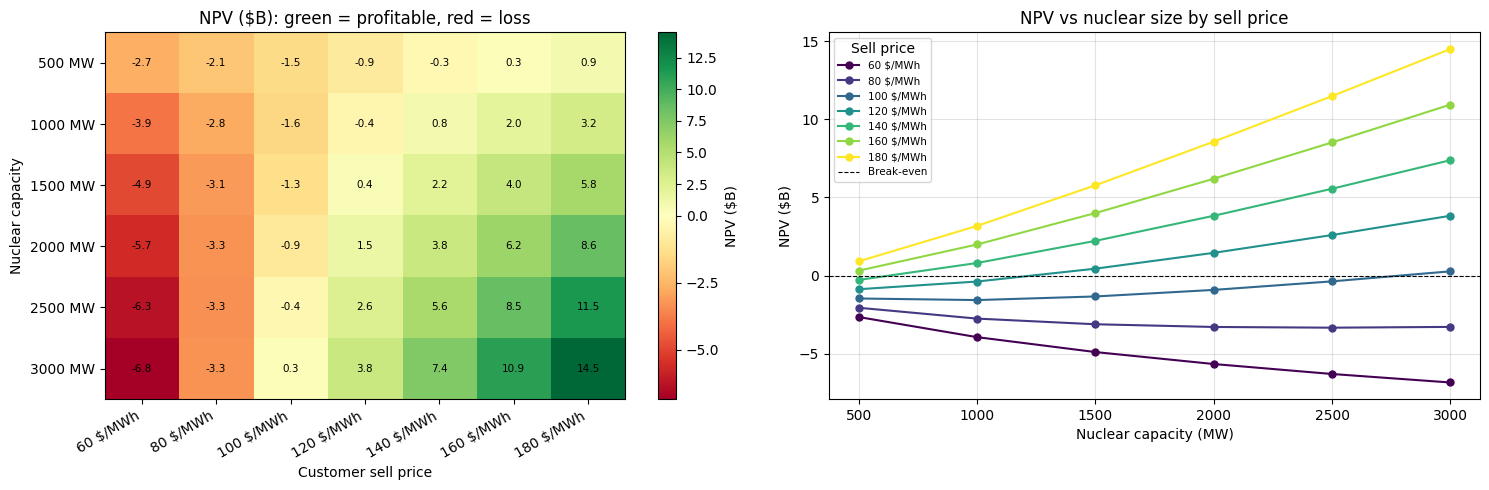

In [8]:
# ── 2-D NPV visualisation ────────────────────────────────────────────────────
import matplotlib.colors as mcolors

sell_labels = [f'{int(p*1000)} $/MWh' for p in SWEEP2_SELL_PRICE]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.subplots_adjust(wspace=0.38)

ax = axes[0]
im = ax.imshow(npv_matrix, aspect='auto', cmap='RdYlGn',
               norm=mcolors.TwoSlopeNorm(vmin=npv_matrix.min(), vcenter=0, vmax=npv_matrix.max()))
ax.set_xticks(range(len(SWEEP2_SELL_PRICE))); ax.set_xticklabels(sell_labels, rotation=30, ha='right')
ax.set_yticks(range(len(SWEEP2_NUC_MW)));    ax.set_yticklabels([f'{m} MW' for m in SWEEP2_NUC_MW])
ax.set_xlabel('Customer sell price'); ax.set_ylabel('Nuclear capacity')
ax.set_title('NPV ($B): green = profitable, red = loss')
plt.colorbar(im, ax=ax, label='NPV ($B)')
for ii in range(len(SWEEP2_NUC_MW)):
    for jj in range(len(SWEEP2_SELL_PRICE)):
        ax.text(jj, ii, f'{npv_matrix[ii,jj]:.1f}', ha='center', va='center', fontsize=7.5)

ax = axes[1]
cmap_c = plt.cm.viridis
for j, sp in enumerate(SWEEP2_SELL_PRICE):
    c = cmap_c(j / (len(SWEEP2_SELL_PRICE) - 1))
    ax.plot(SWEEP2_NUC_MW, npv_matrix[:, j], 'o-', color=c, ms=5, lw=1.5,
            label=f'{int(sp*1000)} $/MWh')
ax.axhline(0, color='black', lw=0.8, ls='--', label='Break-even')
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('NPV ($B)')
ax.set_title('NPV vs nuclear size by sell price')
ax.legend(fontsize=7.5, title='Sell price', loc='upper left')
ax.grid(alpha=0.35)
plt.tight_layout(); plt.show()


## 7. NPV: 1-D Size Sweep at Fixed Sell Price

In [9]:
# ── NPV: 1-D size sweep at a fixed sell price ────────────────────────────────
sell_price_kwh = 0.12  # $/kWh; change as needed

npv_results = []
for nuclear_mw in NUCLEAR_SIZES_MW:
    nuclear_kw = nuclear_mw * 1e3
    h2i.prob.set_val('nuclear.system_capacity',    nuclear_kw,  units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', nuclear_kw,  units='kW')
    h2i.prob.set_val('grid_buy.interconnection_size',  DC_DEMAND_MW * 1e3, units='kW')
    h2i.prob.set_val('grid_sell.interconnection_size', nuclear_kw,         units='kW')
    h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                     sell_price_kwh, units='USD/(kW*h)')
    h2i.run()
    lcoe_mwh = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', 'USD/(kW*h)')[0] * 1000
    npv_b    = h2i.prob.get_val('finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9
    npv_results.append({'nuclear_mw': nuclear_mw, 'lcoe_$/MWh': lcoe_mwh,
                        'sell_price_$/MWh': sell_price_kwh * 1000, 'npv_$B': npv_b})

df_npv = pd.DataFrame(npv_results)
print(df_npv.to_string(index=False))


 nuclear_mw  lcoe_$/MWh  sell_price_$/MWh    npv_$B
        500  133.752963             120.0 -0.873036
        750  121.505526             120.0 -0.685376
       1000  113.676332             120.0 -0.381826
       1250  108.052172             120.0  0.000434
       1500  103.728322             120.0  0.441241
       1750  100.252613             120.0  0.928098
       2000   97.369040             120.0  1.452573
       2250   94.919683             120.0  2.008631
       2500   92.800803             120.0  2.591767
       2750   90.940893             120.0  3.198501
       3000   89.288745             120.0  3.826074
